In [126]:
import warnings
warnings.filterwarnings("ignore")

In [127]:
import pandas as pd

In [128]:
from sklearn.model_selection import train_test_split

In [129]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [130]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [131]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [132]:
X_pima = pima_df[pima_cols[:-1]]

In [133]:
y_pima = pima_df['Outcome']

In [134]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(

    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [136]:
print("Pima Classification Training Set Shape:", X_train_c.shape)

Pima Classification Training Set Shape: (614, 8)


In [137]:
print("Pima Classification Test Set Shape:", X_test_c.shape)

Pima Classification Test Set Shape: (154, 8)


In [138]:
from sklearn.tree import DecisionTreeClassifier

In [139]:
from sklearn.metrics import accuracy_score, classification_report

In [140]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [141]:
tree_clf.fit(X_train_c, y_train_c)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [142]:
clf_preds = tree_clf.predict(X_test_c)

In [143]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")

Decision Tree Classifier Test Accuracy: 79.87%



In [144]:
print("--- Classification Report ---")

--- Classification Report ---


In [145]:
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))

                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



In [146]:
import matplotlib.pyplot as plt

In [147]:
from sklearn.tree import plot_tree

In [148]:
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

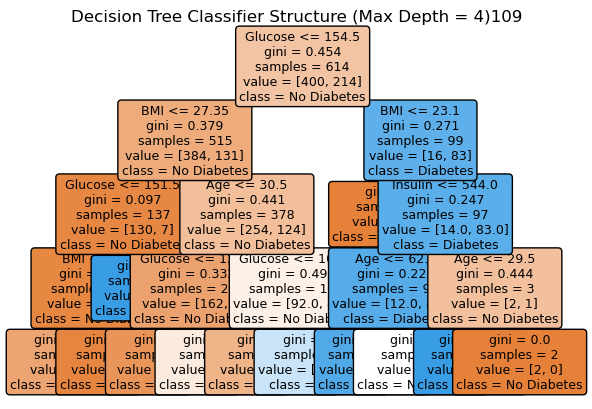

In [26]:
plot_tree(
    tree_clf, 
    feature_names=pima_cols[:-1], 
    class_names=['No Diabetes', 'Diabetes'], 
    filled=True, 
    rounded=True, 
    fontsize=9
)
plt.title("Decision Tree Classifier Structure (Max Depth = 4)109")
plt.show()

In [149]:
from sklearn.tree import DecisionTreeRegressor

In [150]:
from sklearn.preprocessing import StandardScaler

In [151]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [152]:
boston_df = pd.read_csv(boston_url)

In [153]:
boston_features = [col for col in boston_df.columns if col != 'medv']

In [154]:
X_boston = boston_df[boston_features]

In [155]:
y_boston = boston_df['medv']

In [156]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

In [157]:
scaler_r = StandardScaler()

In [158]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [159]:
X_test_r_scaled = scaler_r.transform(X_test_r)

In [160]:
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

In [173]:
tree_reg.fit(X_train_r_scaled, y_train_r)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [161]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


In [174]:
from sklearn.metrics import mean_squared_error, r2_score

In [175]:
import numpy as np

In [176]:
reg_preds = tree_reg.predict(X_test_r_scaled)

In [177]:
mse_val = mean_squared_error(y_test_r, reg_preds)

In [178]:
rmse_val = np.sqrt(mse_val)

In [179]:
r2_val = r2_score(y_test_r, reg_preds)

In [180]:

print(f"Mean Squared Error (MSE): {mse_val:.4f}")

Mean Squared Error (MSE): 8.5539


In [48]:
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")

Root Mean Squared Error (RMSE): 2.9247 ($1000s)


In [181]:
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

R2 Coefficient of Determination: 0.8834



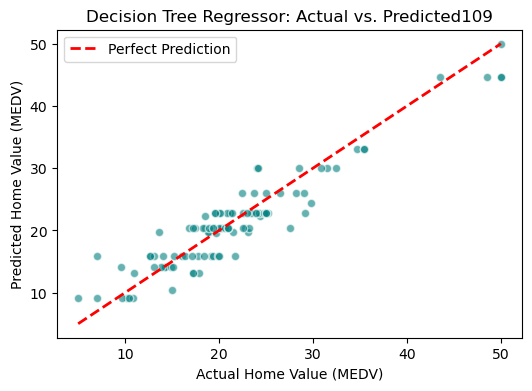

In [99]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Decision Tree Regressor: Actual vs. Predicted109")
plt.xlabel("Actual Home Value (MEDV)")
plt.ylabel("Predicted Home Value (MEDV)")
plt.legend()
plt.show()

In [182]:
import warnings
warnings.filterwarnings("ignore")

In [183]:
import pandas as pd

In [184]:
from sklearn.model_selection import train_test_split

In [185]:
from sklearn.preprocessing import StandardScaler

In [187]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [188]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [189]:
sonar_columns = sonar_features + ['Class']


In [190]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [191]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [192]:
X_sonar = sonar_df[sonar_features]

In [193]:
y_sonar = sonar_df['Class_numeric']

In [194]:
scaler_sonar = StandardScaler()

In [195]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [196]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)


In [197]:
print("Sonar Training Set Shape:", X_train_s.shape)

Sonar Training Set Shape: (145, 60)


In [198]:
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


In [199]:
from sklearn.ensemble import BaggingClassifier

In [200]:
from sklearn.metrics import accuracy_score

In [201]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

In [202]:
bagging_model.fit(X_train_s, y_train_s)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, n_jobs=-1, random_state=42)

In [203]:
bagging_preds = bagging_model.predict(X_test_s)

In [204]:
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)

In [205]:
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")

Bagging Classifier Test Accuracy: 80.95%


In [206]:
from sklearn.ensemble import RandomForestClassifier

In [207]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [208]:
rf_model.fit(X_train_s, y_train_s)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [209]:
rf_preds = rf_model.predict(X_test_s)

In [210]:
rf_accuracy = accuracy_score(y_test_s, rf_preds)

In [211]:
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Classifier Test Accuracy: 82.54%


In [212]:
from sklearn.ensemble import VotingClassifier

In [213]:
from sklearn.linear_model import LogisticRegression

In [214]:
from sklearn.svm import SVC

In [215]:
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]


In [216]:
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

In [217]:
voting_model.fit(X_train_s, y_train_s)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=500,
                                                 random_state=42)),
                             ('dt',
                              DecisionTreeClassifier(max_depth=5,
                                                     random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [218]:
voting_preds = voting_model.predict(X_test_s)

In [219]:
voting_accuracy = accuracy_score(y_test_s, voting_preds)

In [220]:
print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


In [221]:
import matplotlib.pyplot as plt

In [223]:
import seaborn as sns

In [224]:
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})

In [225]:
print("--- Performance Comparison ---")

--- Performance Comparison ---


In [226]:
print(ensemble_results.to_string(index=False))

      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


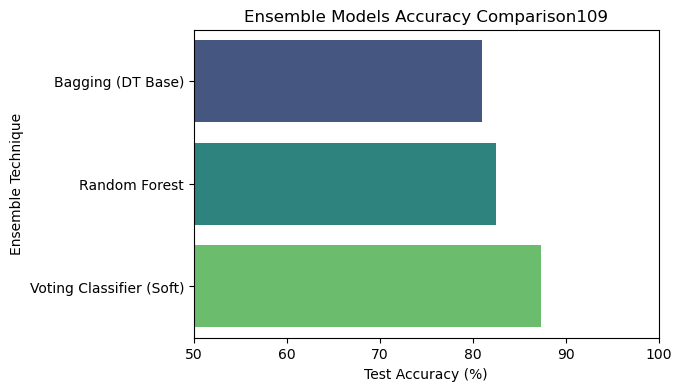

In [227]:
plt.figure(figsize=(6, 4))
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')
plt.xlim([50, 100])
plt.title("Ensemble Models Accuracy Comparison109")
plt.show()

In [228]:
import warnings

In [229]:
warnings.filterwarnings("ignore")

In [230]:
from sklearn.ensemble import AdaBoostClassifier

In [231]:
from sklearn.metrics import accuracy_score

In [232]:
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)

In [233]:
adaboost_model.fit(X_train_s, y_train_s)

AdaBoostClassifier(random_state=42)

In [234]:
ada_preds = adaboost_model.predict(X_test_s)

In [235]:
ada_accuracy = accuracy_score(y_test_s, ada_preds)

In [236]:
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 82.54%


In [237]:
from sklearn.ensemble import GradientBoostingClassifier


In [238]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [239]:
gb_model.fit(X_train_s, y_train_s)

GradientBoostingClassifier(random_state=42)

In [240]:
gb_preds = gb_model.predict(X_test_s)

In [241]:
gb_accuracy = accuracy_score(y_test_s, gb_preds)

In [242]:
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 79.37%


In [246]:
from sklearn.model_selection import GridSearchCV

In [248]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}


In [249]:
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [250]:
grid_gb.fit(X_train_s, y_train_s)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [251]:
best_gb = grid_gb.best_estimator_

In [252]:
tuned_gb_preds = best_gb.predict(X_test_s)

In [253]:
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)

In [254]:
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)

Optimal Hyperparameters Selected: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}


In [255]:
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Tuned Gradient Boosting Test Accuracy: 74.60%


In [256]:
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier', 
        'Random Forest Classifier', 
        'Voting Ensemble (Soft)', 
        'AdaBoost Classifier', 
        'Base Gradient Boosting', 
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100, 
        rf_accuracy * 100, 
        voting_accuracy * 100, 
        ada_accuracy * 100, 
        gb_accuracy * 100, 
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)

In [258]:
print("--- Master Performance Table: Tasks 2 & 3 ---")

--- Master Performance Table: Tasks 2 & 3 ---


In [259]:
print(master_comparison.to_string(index=False))

        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
Random Forest Classifier     82.539683
     AdaBoost Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     79.365079
 Tuned Gradient Boosting     74.603175


In [260]:
import matplotlib.pyplot as plt

In [261]:
import numpy as np

In [262]:
rf_importances = rf_model.feature_importances_

In [263]:
gb_importances = best_gb.feature_importances_

In [264]:
top_indices_rf = np.argsort(rf_importances)[-10:]

In [265]:
top_indices_gb = np.argsort(gb_importances)[-10:]

In [266]:
features_list = [f"F_{i}" for i in range(1, 61)]

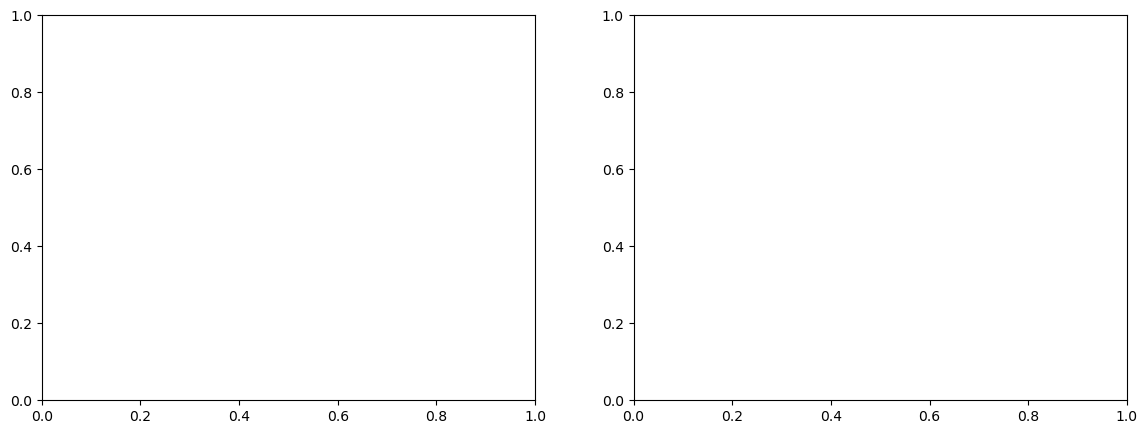

In [267]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))